<a href="https://colab.research.google.com/github/Sleepyheadzd/lire-coleta-de-sinais-/blob/main/coleta_libras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Coleta de Dados de Libras

Este notebook coleta amostras dos sinais **Oi**, **Tudo bem?** e **Tchau** usando a webcam do seu computador.

### Como funciona:
1. Instala as dependências
2. Cria a estrutura de pastas
3. Para cada sinal: exibe um countdown → grava N amostras automaticamente
4. Os frames ficam salvos em `/dados/[SINAL]/[amostra_X]/frame_Y.jpg`

> **Dica:** Execute as células em ordem. Na célula de coleta, preste atenção ao countdown na tela.

## Célula 1 — Instalar dependências

In [ ]:
!pip install mediapipe opencv-python-headless --quiet

import cv2
import mediapipe as mp
import numpy as np
import os
import time
from IPython.display import display, Javascript, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode, b64encode
from PIL import Image
import io

print("libs ok")

libs ok


## Célula 2 — Configurações da coleta

Ajuste aqui quantas amostras e frames por amostra você quer coletar.

In [ ]:
SINAIS = ['Oi', 'Tudo_bem', 'Tchau']
NUM_AMOSTRAS = 30          # aumentar pra 100+ no modelo final
FRAMES_POR_AMOSTRA = 30    # ~1s a 30fps
PASTA_DADOS = 'dados'
PAUSA_ENTRE_AMOSTRAS = 1.5
COUNTDOWN_SEGUNDOS = 3

for sinal in SINAIS:
    for i in range(NUM_AMOSTRAS):
        caminho = os.path.join(PASTA_DADOS, sinal, f'amostra_{i:03d}')
        os.makedirs(caminho, exist_ok=True)

for sinal in SINAIS:
    total = len(os.listdir(os.path.join(PASTA_DADOS, sinal)))
    print(f'dados/{sinal}/ -> {total} pastas')

dados/Oi/ -> 30 pastas
dados/Tudo_bem/ -> 30 pastas
dados/Tchau/ -> 30 pastas


## Célula 3 — Funções auxiliares de webcam

O Colab não tem acesso direto à câmera, então usamos JavaScript para capturar frames do navegador e enviá-los ao Python via base64.

In [ ]:
def iniciar_webcam():
    js = Javascript('''
        async function iniciarCamera() {
            // evita criar mais de uma webcam
            if (document.getElementById('camera-box')) return;

            const box = document.createElement('div');
            box.id = 'camera-box';
            box.style.position = 'fixed';
            box.style.top = '12px';
            box.style.right = '12px';
            box.style.zIndex = '9999';
            box.style.background = '#111';
            box.style.border = '2px solid #22c55e';
            box.style.borderRadius = '10px';
            box.style.overflow = 'hidden';
            box.style.boxShadow = '0 4px 12px rgba(0,0,0,0.3)';

            const video = document.createElement('video');
            video.id = 'webcam-video';
            video.width = 320;
            video.height = 240;
            video.autoplay = true;
            video.playsInline = true;

            const status = document.createElement('span');
            status.id = 'webcam-status';
            status.innerText = '● câmera ligada';
            status.style.position = 'absolute';
            status.style.top = '8px';
            status.style.left = '8px';
            status.style.padding = '3px 7px';
            status.style.fontSize = '12px';
            status.style.fontFamily = 'Arial';
            status.style.background = 'rgba(0,0,0,0.5)';
            status.style.color = '#fff';
            status.style.borderRadius = '5px';

            box.appendChild(video);
            box.appendChild(status);
            document.body.appendChild(box);

            const stream = await navigator.mediaDevices.getUserMedia({
                video: true
            });

            video.srcObject = stream;
        }

        iniciarCamera();
    ''')

    display(js)
    time.sleep(2)
    print('Webcam iniciada.')


def capturar_frame():
    js = Javascript('''
        async function capturarFrame() {
            const video = document.getElementById('webcam-video');

            const canvas = document.createElement('canvas');
            canvas.width = video.videoWidth;
            canvas.height = video.videoHeight;

            const ctx = canvas.getContext('2d');
            ctx.drawImage(video, 0, 0);

            return canvas
                .toDataURL('image/jpeg', 0.9)
                .split(',')[1];
        }
    ''')

    display(js)

    data = eval_js('capturarFrame()')

    img = b64decode(data)
    img = Image.open(io.BytesIO(img)).convert('RGB')

    return np.array(img)[:, :, ::-1]


def atualizar_status(texto, cor='#ffffff'):
    js = Javascript(f'''
        const status = document.getElementById('webcam-status');

        if (status) {{
            status.innerText = `{texto}`;
            status.style.color = `{cor}`;
        }}
    ''')

    display(js)


def encerrar_webcam():
    js = Javascript('''
        const video = document.getElementById('webcam-video');

        if (video && video.srcObject) {
            video.srcObject.getTracks().forEach(track => track.stop());
        }

        const box = document.getElementById('camera-box');

        if (box) {
            box.remove();
        }
    ''')

    display(js)

    print('Webcam encerrada.')


print('Funções carregadas.')

Funções carregadas.


## Célula 4 — Coleta principal

Execute esta célula e siga as instruções na tela.

Para cada sinal:
- Você verá **"PREPARE-SE: [Sinal] — Amostra X/N"** no console
- Um countdown de 3s aparece no label da câmera
- Durante a gravação, execute o sinal de forma natural
- Repita N vezes, variando levemente a velocidade e posição

In [ ]:
iniciar_webcam()

total_coletado = 0

for sinal in SINAIS:

    print('\n' + '=' * 50)
    print(f'Sinal atual: {sinal.upper().replace("_", " ")}')
    print('=' * 50)

    print(f'Faça {NUM_AMOSTRAS} repetições desse sinal.')
    input('Pressione Enter para começar...')

    for amostra_idx in range(NUM_AMOSTRAS):

        pasta_amostra = os.path.join(
            PASTA_DADOS,
            sinal,
            f'amostra_{amostra_idx:03d}'
        )

        print(f'\nAmostra {amostra_idx + 1}/{NUM_AMOSTRAS}')

        # contagem regressiva
        for t in range(COUNTDOWN_SEGUNDOS, 0, -1):
            atualizar_status(
                f'Preparando... {t}s',
                cor='#facc15'
            )

            print(f'Começando em {t}...', end='\r')
            time.sleep(1)

        atualizar_status(
            f'Gravando: {sinal.replace("_", " ")}',
            cor='#f87171'
        )

        print('Capturando frames...')

        frames_gravados = 0

        for frame_idx in range(FRAMES_POR_AMOSTRA):

            frame = capturar_frame()

            caminho_frame = os.path.join(
                pasta_amostra,
                f'frame_{frame_idx:03d}.jpg'
            )

            cv2.imwrite(caminho_frame, frame)

            frames_gravados += 1

        total_coletado += 1

        atualizar_status(
            'Amostra salva',
            cor='#4ade80'
        )

        print(f'{frames_gravados} frames salvos com sucesso.')

        time.sleep(PAUSA_ENTRE_AMOSTRAS)

    print(f'\nColeta do sinal "{sinal}" finalizada.')

encerrar_webcam()

print('\n' + '=' * 50)
print('Coleta concluída')
print(f'Total de amostras: {total_coletado}')
print(f'Total de frames: {total_coletado * FRAMES_POR_AMOSTRA}')
print(f'Dados salvos em: ./{PASTA_DADOS}/')
print('=' * 50)

<IPython.core.display.Javascript object>

Webcam iniciada.

Sinal atual: OI
Faça 30 repetições desse sinal.


KeyboardInterrupt: Interrupted by user

## Célula 5 — Verificação dos dados coletados

Confira se tudo foi salvo corretamente antes de passar para a Etapa 2.

Resumo da coleta:

Oi           |  30 amostras |     0 frames | 30 incompleta(s)
Tudo bem     |  30 amostras |     0 frames | 30 incompleta(s)
Tchau        |  30 amostras |     0 frames | 30 incompleta(s)

Total de frames: 0

Mostrando exemplos...



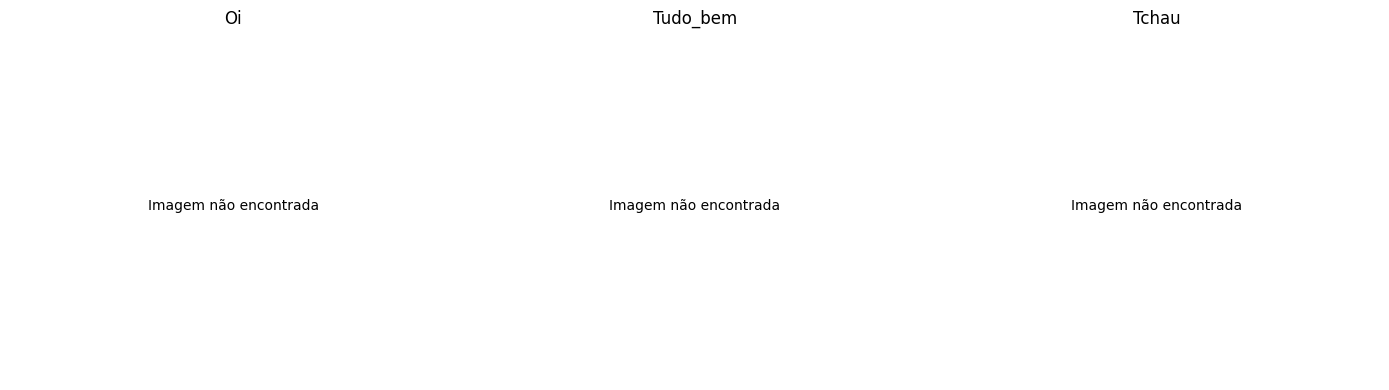


Preview salvo em "preview_coleta.png"


In [ ]:
print('Resumo da coleta:\n')

total_frames = 0

for sinal in SINAIS:

    pasta_sinal = os.path.join(PASTA_DADOS, sinal)

    amostras = sorted(os.listdir(pasta_sinal))

    frames_por_sinal = 0
    amostras_com_problema = 0

    for amostra in amostras:

        pasta_amostra = os.path.join(pasta_sinal, amostra)

        frames = [
            f for f in os.listdir(pasta_amostra)
            if f.endswith('.jpg')
        ]

        qtd_frames = len(frames)

        frames_por_sinal += qtd_frames

        if qtd_frames != FRAMES_POR_AMOSTRA:
            amostras_com_problema += 1

    total_frames += frames_por_sinal

    print(
        f'{sinal.replace("_", " "):12s} | '
        f'{len(amostras):3d} amostras | '
        f'{frames_por_sinal:5d} frames',
        end=''
    )

    if amostras_com_problema > 0:
        print(f' | {amostras_com_problema} incompleta(s)')
    else:
        print(' | ok')

print(f'\nTotal de frames: {total_frames}')


# preview de imagens
print('\nMostrando exemplos...\n')

import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    1,
    len(SINAIS),
    figsize=(14, 4)
)

for ax, sinal in zip(axes, SINAIS):

    caminho = os.path.join(
        PASTA_DADOS,
        sinal,
        'amostra_000',
        'frame_015.jpg'
    )

    if os.path.exists(caminho):

        img = cv2.imread(caminho)

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        ax.imshow(img)

        ax.set_title(
            sinal.replace('_', ' '),
            fontsize=12
        )

    else:

        ax.text(
            0.5,
            0.5,
            'Imagem não encontrada',
            ha='center',
            va='center'
        )

        ax.set_title(sinal)

    ax.axis('off')

plt.tight_layout()

plt.savefig(
    'preview_coleta.png',
    dpi=120,
    bbox_inches='tight'
)

plt.show()

print('\nPreview salvo em "preview_coleta.png"')

## Célula 6 — Compactar e baixar os dados (opcional)

Backup dos frames


In [ ]:
import shutil
from google.colab import files

print('Compactando os arquivos...')

shutil.make_archive(
    'dados_libras',
    'zip',
    '.',
    'dados'
)

print('Arquivo "dados_libras.zip" criado com sucesso.')

# Para baixar o arquivo:
# files.download('dados_libras.zip')